# Machine Learning Potential for Formic Acid Dimer

This notebook prepares data for training a machine learning interatomic potential for the formic acid dimer. The input data consist of previously prepared ORCA-based trajectories and force files for two simulation temperatures: 298 K and 500 K.

The notebook reads the XYZ trajectory files and the corresponding force files, converts them into the DeepMD-kit data format, prepares the training input file, and provides basic checks and visualizations of the dataset.

## Input files

The notebook uses the following input files:

- `trajectory_298.xyz` — ORCA-based trajectory for the formic acid dimer at 298 K
- `forces_298.xyz` — corresponding force data for the 298 K trajectory
- `trajectory_500.xyz` — ORCA-based trajectory for the formic acid dimer at 500 K
- `forces_500.xyz` — corresponding force data for the 500 K trajectory

These files were prepared before running this notebook and are used here as the starting point for dataset conversion and machine learning potential preparation.

The workflow was developed based on the DeePMD-kit hands-on tutorial and adapted to the formic acid dimer system
https://tutorials.deepmodeling.com/en/latest/Tutorials/DeePMD-kit/learnDoc/Handson-Tutorial%28v2.0.3%29.html

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
# choose you folder for saving your output files
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

for item in drive_root.iterdir():
    print(item)

/content/drive/MyDrive/Taco Hemingway Europa Special Edition.mp3
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/ML


In [ ]:
!pip install ase
!pip install dpdata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 9.0 MB/s eta 0:00:00


In [ ]:
!pip uninstall -y tensorflow deepmd-kit
!pip install tensorflow==2.21.0 deepmd-kit --no-binary deepmd-kit

Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached h5py-3.14.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.4 MB/s eta 0:00:00
Using cached h5py-3.14.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.9 MB)
Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl (327 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)

import deepmd
print("DeepMD imported successfully")

TensorFlow: 2.21.0
DeepMD imported successfully


In [ ]:
!rm -rf /content/Gabii3355.github.io
!git clone --depth 1 https://github.com/Gabii3355/Gabii3355.github.io.git /content/Gabii3355.github.io

Cloning into '/content/Gabii3355.github.io'...
remote: Enumerating objects: 134, done.
remote: Counting objects: 100% (134/134), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 134 (delta 14), reused 103 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (134/134), 25.74 MiB | 7.25 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [ ]:
from pathlib import Path

# paste here your google drive path
PROJECT_DIR = Path("/content/drive/MyDrive/ML/formic_acid_ML")
RAW_DIR = PROJECT_DIR / "data" / "raw"

TRAJECTORY_298 = RAW_DIR / "trajectory_298.xyz"
FORCES_298 = RAW_DIR / "forces_298.xyz"
TRAJECTORY_500 = RAW_DIR / "trajectory_500.xyz"
FORCES_500 = RAW_DIR / "forces_500.xyz"

RAW_DIR.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Raw data folder:", RAW_DIR)

Project folder: /content/drive/MyDrive/ML/formic_acid_ML
Raw data folder: /content/drive/MyDrive/ML/formic_acid_ML/data/raw


In [ ]:
import shutil

GITHUB_RAW_DIR = Path("/content/Gabii3355.github.io/projects/deepmd/data/raw")

for file_path in GITHUB_RAW_DIR.glob("*"):
    if file_path.is_file():
        destination = RAW_DIR / file_path.name
        shutil.copy2(file_path, destination)
        print(f"Copied: {file_path.name} -> {destination}")

Copied: forces_500.xyz -> /content/drive/MyDrive/ML/formic_acid_ML/data/raw/forces_500.xyz
Copied: trajectory_500.xyz -> /content/drive/MyDrive/ML/formic_acid_ML/data/raw/trajectory_500.xyz
Copied: trajectory_298.xyz -> /content/drive/MyDrive/ML/formic_acid_ML/data/raw/trajectory_298.xyz
Copied: forces_298.xyz -> /content/drive/MyDrive/ML/formic_acid_ML/data/raw/forces_298.xyz


### Content of `trajectory.xyz`

In [ ]:
print(f"Displaying first 10 lines of {TRAJECTORY_298}:")

with open(TRAJECTORY_298, "r") as f:
    for i, line in enumerate(f):
        if i >= 10:
            break
        print(line.strip())


Displaying first 10 lines of /content/drive/MyDrive/ML/formic_acid_ML/data/raw/trajectory_298.xyz:
10
# ORCA AIMD Position Step 0, t=0.00 fs, E_Pot=-378.87723896 Hartree, Unit is Angstrom
H     -2.5898860495     -0.5548979311     -0.4381717129
C     -1.8883686880     -1.4254214536     -0.4362223298
O     -1.2200390767     -1.6934440470      0.5682407369
O     -1.8866384608     -2.0650807788     -1.5750642937
H     -1.2259610993     -2.8659555634     -1.5377286697
H     -0.2355286972     -2.8823536232      0.6351176207
O      0.4246675954     -3.6836300881      0.6725367249
C      0.4258180534     -4.3236834913     -0.4661098869


In [ ]:
print(f"Displaying first 10 lines of {TRAJECTORY_500}:")

with open(TRAJECTORY_500, "r") as f:
    for i, line in enumerate(f):
        if i >= 10:
            break
        print(line.strip())

Displaying first 10 lines of /content/drive/MyDrive/ML/formic_acid_ML/data/raw/trajectory_500.xyz:
10
# ORCA AIMD Position Step 0, t=0.00 fs, E_Pot=-378.87723896 Hartree, Unit is Angstrom
H     -2.5898860495     -0.5548979311     -0.4381717129
C     -1.8883686880     -1.4254214536     -0.4362223298
O     -1.2200390767     -1.6934440470      0.5682407369
O     -1.8866384608     -2.0650807788     -1.5750642937
H     -1.2259610993     -2.8659555634     -1.5377286697
H     -0.2355286972     -2.8823536232      0.6351176207
O      0.4246675954     -3.6836300881      0.6725367249
C      0.4258180534     -4.3236834913     -0.4661098869


In [ ]:
print(f"Displaying last 11 lines of {FORCES_500}:")

with open(FORCES_500, "r") as f:
    lines = f.readlines()

for line in lines[-11:]:
    print(line.strip())

Displaying last 11 lines of /content/drive/MyDrive/ML/formic_acid_ML/data/raw/forces_500.xyz:
# ORCA AIMD Force Step 1000, t=500.00 fs, E_Pot=-378.86645322 Hartree, Unit is Hartree/Angstrom
H      0.0000488875     -0.0135226929     -0.0146062856
C     -0.0452037675      0.0324011556     -0.0106599579
O      0.0235467224     -0.0087308295      0.0239013282
O     -0.0039503064     -0.0017585091     -0.0041831872
H      0.0103043596     -0.0058658808      0.0052814232
H      0.0315061157     -0.0026265111     -0.0096653991
O      0.0803279164     -0.0307900175     -0.0717607751
C     -0.0833859417      0.0399398084      0.1566188008
O     -0.0034834912     -0.0132668833     -0.0734574937
H     -0.0097104948      0.0042203602     -0.0014684535


In [ ]:
print(f"Displaying last 11 lines of {FORCES_298}:")

with open(FORCES_298, "r") as f:
    lines = f.readlines()

for line in lines[-11:]:
    print(line.strip())

Displaying last 11 lines of /content/drive/MyDrive/ML/formic_acid_ML/data/raw/forces_298.xyz:
# ORCA AIMD Force Step 1000, t=500.00 fs, E_Pot=-378.86967213 Hartree, Unit is Hartree/Angstrom
H     -0.0119034464     -0.0158704309     -0.0087068634
C     -0.0206297832      0.0006561670     -0.0358522721
O      0.0011603897      0.0196018655      0.0416725606
O      0.0641644073      0.0097848462      0.0192192215
H     -0.0424825255     -0.0147521214     -0.0206087478
H     -0.0127821637     -0.0198136616     -0.0285750242
O      0.0560885198      0.0068793741      0.0067159340
C     -0.0313171931      0.0498491963      0.0975408712
O      0.0067408404     -0.0307870506     -0.0594225320
H     -0.0090390454     -0.0055481845     -0.0119831480


### Make train, test and validation files
######The dataset was split by temperature to evaluate whether a model trained on higher-temperature configurations can transfer to lower-temperature structures. The 500 K dataset was used for training, while the 298 K dataset was divided into validation and test subsets. The validation subset was used to monitor model performance during training, and the independent test subset was kept for final evaluation.

In [ ]:
import random

# PATHS

DEEPMD_DIR = PROJECT_DIR / "data" / "deepmd"

TRAIN_DIR = DEEPMD_DIR / "train"
VALIDATION_DIR = DEEPMD_DIR / "validation"
TEST_DIR = DEEPMD_DIR / "test"

for folder in [TRAIN_DIR, VALIDATION_DIR, TEST_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# FUNCTIONS
def read_xyz_frames(path): # Read a multi-frame XYZ file as a list of frames

    frames = []

    with open(path, "r") as f:
        while True:
            first = f.readline()

            if not first:
                break

            if not first.strip():
                continue

            n_atoms = int(first.strip())
            comment = f.readline()
            atoms = [f.readline() for _ in range(n_atoms)]

            frames.append([first, comment] + atoms)

    return frames


def write_xyz_frames(frames, path): # Write selected XYZ frames to file
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w") as f:
        for frame in frames:
            f.writelines(frame)


def split_validation_test(n_frames, validation_ratio=0.20, seed=42):
    """
    Split indices into validation and test subsets.
    Used only for the 298 K dataset.
    """
    indices = list(range(n_frames))

    random.seed(seed)
    random.shuffle(indices)

    n_validation = int(validation_ratio * n_frames)

    validation_idx = indices[:n_validation]
    test_idx = indices[n_validation:]

    return validation_idx, test_idx

# READ DATA

trajectory_500_frames = read_xyz_frames(TRAJECTORY_500)
forces_500_frames = read_xyz_frames(FORCES_500)

trajectory_298_frames = read_xyz_frames(TRAJECTORY_298)
forces_298_frames = read_xyz_frames(FORCES_298)

# CHECK FRAME CONSISTENCY

if len(trajectory_500_frames) != len(forces_500_frames):
    raise ValueError(
        f"Frame mismatch for 500 K: "
        f"{len(trajectory_500_frames)} trajectory frames, "
        f"{len(forces_500_frames)} force frames"
    )

if len(trajectory_298_frames) != len(forces_298_frames):
    raise ValueError(
        f"Frame mismatch for 298 K: "
        f"{len(trajectory_298_frames)} trajectory frames, "
        f"{len(forces_298_frames)} force frames"
    )


# TRAINING SET = FULL 500 K DATASET

write_xyz_frames(
    trajectory_500_frames,
    TRAIN_DIR / "trajectory_train_500K.xyz"
)

write_xyz_frames(
    forces_500_frames,
    TRAIN_DIR / "forces_train_500K.xyz"
)

# VALIDATION AND TEST SETS = SPLIT 298 K DATASET

validation_idx, test_idx = split_validation_test(
    n_frames=len(trajectory_298_frames),
    validation_ratio=0.20,
    seed=42
)

write_xyz_frames(
    [trajectory_298_frames[i] for i in validation_idx],
    VALIDATION_DIR / "trajectory_validation_298K.xyz"
)

write_xyz_frames(
    [forces_298_frames[i] for i in validation_idx],
    VALIDATION_DIR / "forces_validation_298K.xyz"
)

write_xyz_frames(
    [trajectory_298_frames[i] for i in test_idx],
    TEST_DIR / "trajectory_test_298K.xyz"
)

write_xyz_frames(
    [forces_298_frames[i] for i in test_idx],
    TEST_DIR / "forces_test_298K.xyz"
)

# PRINT SUMMARY

print("Dataset split completed.")
print("=" * 60)
print(f"Training set:   500 K, {len(trajectory_500_frames)} frames")
print(f"Validation set: 298 K, {len(validation_idx)} frames")
print(f"Test set:       298 K, {len(test_idx)} frames")
print()
print("Files saved in:")
print(DEEPMD_DIR)

Dataset split completed.
Training set:   500 K, 1001 frames
Validation set: 298 K, 200 frames
Test set:       298 K, 801 frames

Files saved in:
/content/drive/MyDrive/ML/formic_acid_ML/data/deepmd


Change input files into npy format

In [ ]:
import re
import ase
from ase.io import read
import dpdata
import shutil
from pathlib import Path
import numpy as np

# PATHS
NPY_DIR = DEEPMD_DIR / "npy_format"
NPY_DIR.mkdir(parents=True, exist_ok=True)
split_files = {
    "train": {
        "trajectory": DEEPMD_DIR / "train" / "trajectory_train_500K.xyz",
        "forces": DEEPMD_DIR / "train" / "forces_train_500K.xyz",
        "output": NPY_DIR / "train",
    },
    "validation": {
        "trajectory": DEEPMD_DIR / "validation" / "trajectory_validation_298K.xyz",
        "forces": DEEPMD_DIR / "validation" / "forces_validation_298K.xyz",
        "output": NPY_DIR / "validation",
    },
    "test": {
        "trajectory": DEEPMD_DIR / "test" / "trajectory_test_298K.xyz",
        "forces": DEEPMD_DIR / "test" / "forces_test_298K.xyz",
        "output": NPY_DIR / "test",
    },
}
# FUNCTIONS
HARTREE_TO_EV = 27.211386245988
def extract_energy_from_comment(comment):
    """
    Extract E_Pot value from an XYZ comment line.
    Example:
    # ORCA AIMD Position Step 0, t=0.00 fs, E_Pot=-378.87723896 Hartree
    """
    match = re.search(r"E_Pot\s*=\s*([-+]?\d+(?:\.\d+)?(?:[EeDd][-+]?\d+)?)", comment)

    if match is None:
        raise ValueError(f"Could not find E_Pot in comment line:\n{comment}")

    return float(match.group(1).replace("D", "E"))


def read_forces_and_energies(forces_path):
    """
    Read a multi-frame XYZ-like force file.

    Input units from ORCA:
    energy: Hartree
    forces: Hartree/Angstrom

    Output units for DeepMD/LAMMPS metal units:
    energy: eV
    forces: eV/Angstrom
    """
    energies = []
    forces = []

    with open(forces_path, "r") as f:
        while True:
            first_line = f.readline()

            if not first_line:
                break

            if not first_line.strip():
                continue

            n_atoms = int(first_line.strip())
            comment = f.readline().strip()

            # Energy conversion: Hartree -> eV
            energy_hartree = extract_energy_from_comment(comment)
            energy_ev = energy_hartree * HARTREE_TO_EV
            energies.append(energy_ev)

            frame_forces = []

            for _ in range(n_atoms):
                parts = f.readline().split()

                if len(parts) < 4:
                    raise ValueError(
                        f"Incorrect force line in {forces_path}:\n{parts}"
                    )

                # Force conversion: Hartree/Angstrom -> eV/Angstrom
                fx, fy, fz = [
                    float(x) * HARTREE_TO_EV
                    for x in parts[1:4]
                ]

                frame_forces.append([fx, fy, fz])

            forces.append(frame_forces)

    return np.array(energies), np.array(forces)


def convert_xyz_to_deepmd_npy(trajectory_path, forces_path, output_dir):
    """
    Convert trajectory + force XYZ files into DeepMD npy format.
    """
    print(f"\nProcessing:")
    print(f"Trajectory: {trajectory_path}")
    print(f"Forces:     {forces_path}")

    if not trajectory_path.exists():
        raise FileNotFoundError(f"Missing trajectory file: {trajectory_path}")

    if not forces_path.exists():
        raise FileNotFoundError(f"Missing forces file: {forces_path}")

    # Read molecular structures from trajectory file
    ase_frames = ase.io.read(str(trajectory_path), index=":", format="extxyz")

    data = dpdata.System()

    for atoms in ase_frames:
        data.append(dpdata.System(atoms, fmt="ase/structure"))

    n_frames = len(data)
    n_atoms = data.get_natoms()

    # Read energies and forces from forces file
    energies, forces = read_forces_and_energies(forces_path)

    # Check consistency
    if len(energies) != n_frames:
        raise ValueError(
            f"Energy/frame mismatch for {forces_path}: "
            f"{len(energies)} energies, but {n_frames} trajectory frames."
        )

    if forces.shape != (n_frames, n_atoms, 3):
        raise ValueError(
            f"Force shape mismatch for {forces_path}: "
            f"expected {(n_frames, n_atoms, 3)}, got {forces.shape}."
        )

    # Assign labels required by DeepMD
    data.data["energies"] = energies
    data.data["forces"] = forces

    # Remove old output if it exists
    if output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)

    # Save in DeepMD npy format
    data.to("deepmd/npy", str(output_dir))

    print(f"Saved DeepMD npy data to: {output_dir}")
    print(f"Frames: {n_frames}")
    print(f"Atoms per frame: {n_atoms}")


# CONVERT TRAIN / VALIDATION / TEST

for split_name, paths in split_files.items():
    print("\n" + "=" * 70)
    print(f"Converting {split_name.upper()} set")

    convert_xyz_to_deepmd_npy(
        trajectory_path=paths["trajectory"],
        forces_path=paths["forces"],
        output_dir=paths["output"],
    )


print("\nAll datasets converted to DeepMD npy format.")
print("Output folder:")
print(NPY_DIR)


Converting TRAIN set

Processing:
Trajectory: /content/drive/MyDrive/ML/formic_acid_ML/data/deepmd/train/trajectory_train_500K.xyz
Forces:     /content/drive/MyDrive/ML/formic_acid_ML/data/deepmd/train/forces_train_500K.xyz
Saved DeepMD npy data to: /content/drive/MyDrive/ML/formic_acid_ML/data/deepmd/npy_format/train
Frames: 1001
Atoms per frame: 10

Converting VALIDATION set

Processing:
Trajectory: /content/drive/MyDrive/ML/formic_acid_ML/data/deepmd/validation/trajectory_validation_298K.xyz
Forces:     /content/drive/MyDrive/ML/formic_acid_ML/data/deepmd/validation/forces_validation_298K.xyz
Saved DeepMD npy data to: /content/drive/MyDrive/ML/formic_acid_ML/data/deepmd/npy_format/validation
Frames: 200
Atoms per frame: 10

Converting TEST set

Processing:
Trajectory: /content/drive/MyDrive/ML/formic_acid_ML/data/deepmd/test/trajectory_test_298K.xyz
Forces:     /content/drive/MyDrive/ML/formic_acid_ML/data/deepmd/test/forces_test_298K.xyz
Saved DeepMD npy data to: /content/drive/My

In [ ]:
cat /content/drive/MyDrive/ML/formic_acid_ML/data/deepmd/npy_format/test/type.raw

0
1
2
2
0
0
2
1
2
0


In [ ]:
cat /content/drive/MyDrive/ML/formic_acid_ML/data/deepmd/npy_format/test/type_map.raw

H
C
O


###Training data on 500K -> make deepMD input json training data: folder 500K validation data: folder 298K
#### This step creates the `input.json` file required by DeepMD-kit for model training. The configuration defines the model architecture, descriptor settings, learning rate schedule, loss function weights, and the paths to the training and validation datasets.


In [ ]:
import json
import os

TRAIN_SYSTEM = NPY_DIR / "train"
VALIDATION_SYSTEM = NPY_DIR / "validation"
TEST_SYSTEM = NPY_DIR / "test"

INPUT_JSON =  PROJECT_DIR / "input.json"

input_config = {
    "model": {
        "type_map": ["H", "C", "O"],
        "descriptor": {
            "type": "se_e2_a",
            "rcut": 6.00,
            "rcut_smth": 0.50,
            "sel": [4, 2, 4],
            "neuron": [10,20,40],
            "resnet_dt": False,
            "axis_neuron": 4,
            "seed": 1
        },
        "fitting_net": {
            "neuron": [100, 100, 100],
            "resnet_dt": True,
            "seed": 1
        }
    },

    "learning_rate": {
        "type": "exp",
        "decay_steps": 5000,
        "start_lr": 0.001,
        "stop_lr": 3.51e-8
    },

    "loss": {
        "type": "ener",
        "start_pref_e": 0.02,
        "limit_pref_e": 1,
        "start_pref_f": 1000,
        "limit_pref_f": 1,
        "start_pref_v": 0,
        "limit_pref_v": 0
    },

    "training": {
        "training_data": {
            "systems": [str(TRAIN_SYSTEM)],
            "batch_size": "auto"
        },

        "validation_data": {
            "systems": [str(VALIDATION_SYSTEM)],
            "batch_size": "auto",
            "numb_btch": 1
        },

        "numb_steps": 50000,
        "seed": 10,
        "disp_file": "lcurve.out",
        "disp_freq": 1000,
        "save_freq": 10000
    }
}


# SAVE INPUT.JSON

INPUT_JSON.parent.mkdir(parents=True, exist_ok=True)

with open(INPUT_JSON, "w") as f:
    json.dump(input_config, f, indent=4)

print(f"DeepMD input configuration saved to: {INPUT_JSON}")

DeepMD input configuration saved to: /content/drive/MyDrive/ML/formic_acid_ML/input.json


In [ ]:
# Output folder for DeepMD training results
OUT_TRAIN_DIR = PROJECT_DIR / "train_out"

# Create output folder
OUT_TRAIN_DIR .mkdir(parents=True, exist_ok=True)

# Check if input.json exists
if not INPUT_JSON.exists():
    raise FileNotFoundError(f"input.json not found: {INPUT_JSON}")

print("Project directory:", PROJECT_DIR)
print("Output directory:", OUT_TRAIN_DIR)
print("Input JSON:", INPUT_JSON)

Project directory: /content/drive/MyDrive/ML/formic_acid_ML
Output directory: /content/drive/MyDrive/ML/formic_acid_ML/train_out
Input JSON: /content/drive/MyDrive/ML/formic_acid_ML/input.json


In [ ]:
%cd  /content/drive/MyDrive/ML/formic_acid_ML/train_out

/content/drive/MyDrive/ML/formic_acid_ML/train_out


Now that `deepmd-kit` is installed and the `input.json` file is ready, you can start the DeepMD training using the `dp train` command:

In [ ]:
!dp train "/content/drive/MyDrive/ML/formic_acid_ML/input.json"

I0000 00:00:1784098344.328314    3276 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784098347.787657    3276 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
Switch to serial execution due to lack of horovod module.
[2026-07-15 06:52:40,275] DEEPMD INFO    Calculate neighbor statistics... (add --skip-neighbor-stat to skip this step)
E0000 00:00:1784098360.326051    3276 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
[2026-07-15 06:52:40,326] DEEPMD WARNING You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The defaul

In [ ]:
!find /content -name "lcurve.out"

/content/drive/MyDrive/ML/formic_acid_ML/train_out/lcurve.out


In [ ]:
 cat /content/drive/MyDrive/ML/formic_acid_ML/train_out/lcurve.out

# step       rmse_val    rmse_trn    rmse_e_val  rmse_e_trn    rmse_f_val  rmse_f_trn   lr      
# If there is no available reference data, rmse_*_{val,trn} will print nan
      0      2.70e+01    3.13e+01      1.01e-01    1.09e-01      8.53e-01    9.89e-01    1.0e-03
   1000      4.60e+00    5.60e+00      5.25e-01    5.27e-01      1.45e-01    1.77e-01    1.0e-03
   2000      2.85e+00    4.31e+00      1.12e-01    1.14e-01      9.03e-02    1.36e-01    1.0e-03
   3000      2.05e+00    3.13e+00      1.23e-02    1.28e-02      6.48e-02    9.90e-02    1.0e-03
   4000      2.30e+00    1.92e+00      1.50e-03    2.65e-03      7.28e-02    6.07e-02    1.0e-03
   5000      9.76e-01    1.55e+00      1.39e-02    1.42e-02      5.14e-02    8.20e-02    3.6e-04
   6000      8.11e-01    1.09e+00      5.97e-04    8.10e-04      4.28e-02    5.74e-02    3.6e-04
   7000      7.55e-01    1.04e+00      2.11e-03    1.50e-03      3.98e-02    5.50e-02    3.6e-04
   8000      7.41e-01    1.13e+00      1.55e-03    2

In [ ]:
#restart calculations from json.input: dp train  --restart model.ckpt  input.json

In [ ]:
import numpy as np
from pathlib import Path

# Choose which dataset to inspect: "train", "validation", or "test"
dataset_name = "train"

path = NPY_DIR / dataset_name

energy = np.load(path / "set.000" / "energy.npy")
force = np.load(path / "set.000" / "force.npy")

print(f"Dataset: {dataset_name}")
print(f"Path: {path}")

print("\nEnergy array shape:")
print(energy.shape)

print("\nForce array shape:")
print(force.shape)

print("\nFirst energies:")
print(energy[:5])

print("\nEnergy range:")
print(energy.min(), energy.max())

print("\nForce range:")
print(force.min(), force.max())

Dataset: train
Path: /content/drive/MyDrive/ML/formic_acid_ML/data/deepmd/npy_format/train

Energy array shape:
(1001, 1)

Force array shape:
(1001, 30)

First energies:
[[-10309.77488915]
 [-10309.75613942]
 [-10309.7038707 ]
 [-10309.62940375]
 [-10309.54946377]]

Energy range:
-10309.774889154052 -10309.18252639166

Force range:
-5.139282621248341 4.615883332193096


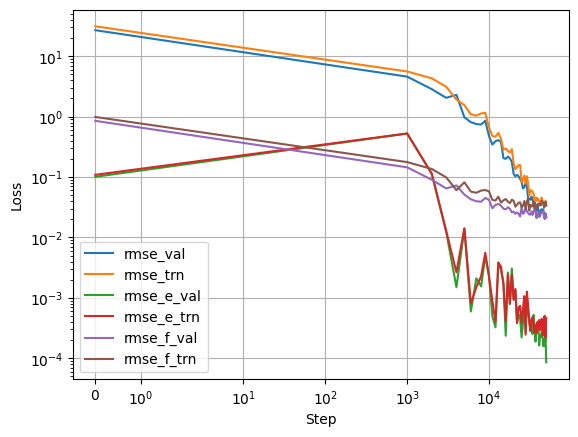

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt("lcurve.out", names=True)
for name in data.dtype.names[1:-1]:
    plt.plot(data['step'], data[name], label=name)
plt.legend()
plt.xlabel('Step')
plt.ylabel('Loss')
plt.xscale('symlog')
plt.yscale('log')
plt.grid()
plt.show()


In [ ]:
%cd /content/drive/MyDrive/ML/formic_acid_ML/train_out/

/content/drive/MyDrive/ML/formic_acid_ML/train_out


In [ ]:
!dp freeze -o graph.pb

I0000 00:00:1784099065.398283    6249 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784099069.725236    6249 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
E0000 00:00:1784099073.821170    6249 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
[2026-07-15 07:04:34,451] DEEPMD INFO    The following nodes will be frozen: ['o_virial', 'fitting_attr/dfparam', 'descrpt_attr/rcut', 't_mesh', 'o_force', 'o_energy', 'o_atom_energy', 'train_attr/training_script', 'model_attr/model_type', 'o_atom_virial', 'descrpt_attr/ntypes', 'model_type', 'model_attr/model_version', 'train_attr/min_nb

In [ ]:
!dp compress -i graph.pb -o graph-compress.pb

I0000 00:00:1784099077.723105    6320 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784099080.376809    6320 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
E0000 00:00:1784099084.036991    6320 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
[2026-07-15 07:04:44,402] DEEPMD INFO    


[2026-07-15 07:04:44,402] DEEPMD INFO    stage 1: compress the model
[2026-07-15 07:04:44,421] DEEPMD WARNING Switch to serial execution due to lack of horovod module.
[2026-07-15 07:04:52,660] DEEPMD INFO     _____               _____   __  __  _____           _     _  _   
[2026-07-15 07:04:52

In [ ]:
!ls

checkpoint			      model.ckpt-30000.index
compress.json			      model.ckpt-30000.meta
graph-compress.pb		      model.ckpt-40000.data-00000-of-00001
graph.pb			      model.ckpt-40000.index
input_v2_compat.json		      model.ckpt-40000.meta
lcurve.out			      model.ckpt-50000.data-00000-of-00001
model.ckpt-10000.data-00000-of-00001  model.ckpt-50000.index
model.ckpt-10000.index		      model.ckpt-50000.meta
model.ckpt-10000.meta		      model.ckpt.data-00000-of-00001
model.ckpt-20000.data-00000-of-00001  model.ckpt.index
model.ckpt-20000.index		      model.ckpt.meta
model.ckpt-20000.meta		      model-compression
model.ckpt-30000.data-00000-of-00001  out.json


In [ ]:
import numpy as np

energy = np.load("/content/drive/MyDrive/ML/formic_acid_ML/data/deepmd/npy_format/test/set.000/energy.npy")
print(len(energy))

801


Test the model

In [ ]:
!dp test -m graph-compress.pb -s /content/drive/MyDrive/ML/formic_acid_ML/data/deepmd/npy_format/test/ -n 1001 -d results

I0000 00:00:1784099104.322651    6444 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784099107.167875    6444 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
[2026-07-15 07:05:08,789] DEEPMD WARNING To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
E0000 00:00:1784099109.193913    6444 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
[2026-07-15 07:05:09,541] DEEPMD WARNING You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
[2026-07-15 07:05:09,598] DEEPMD INFO    # ---------------output of dp test--------------- 
[2026-07-15 07:05:09,598] D

The trained DeepMD model was evaluated on an independent test set containing 801 structures. The model achieved an energy RMSE of 2.49 × 10⁻³ eV and a force RMSE of 2.48 × 10⁻² eV/Å. These low errors indicate that the model reproduces the reference ORCA energies and forces with good accuracy on the test data.

#Run MD with LAMMPS
###### This section uses the trained DeepMD potential in a LAMMPS molecular dynamics simulation.  
The file `npconf.lmp` provides the initial structure of the system, while `graph.pb` or `graph-compress.pb` contains the trained machine learning potential.

LAMMPS reads the starting configuration, assigns atom types and masses, and uses `pair_style deepmd` to calculate energies and forces from the trained model. The simulation is then propagated using these predicted forces. This step demonstrates how the trained model can be applied to perform MD simulations without recalculating quantum-mechanical forces with ORCA.

In [ ]:
!pip install -q condacolab

In [ ]:
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:21
🔁 Restarting kernel...


In [ ]:
!conda --version

conda 24.11.2


In [ ]:
!conda install -y -c conda-forge deepmd-kit lammps

Streaming output truncated to the last 5000 lines.
    giflib-5.2.2               |       hd590300_0          75 KB  conda-forge
    gmp-6.3.0                  |       hac33072_2         449 KB  conda-forge
    gmpy2-2.3.0                |  py311h92a432a_1         236 KB  conda-forge
    google-pasta-0.2.0         |     pyhd8ed1ab_2          48 KB  conda-forge
    greenlet-3.5.3             |  py311hc665b79_0         264 KB  conda-forge
    grpcio-1.78.1              |  py311h3aa0767_0         861 KB  conda-forge
    gsl-2.7                    |       he838d99_0         3.2 MB  conda-forge
    gxx_impl_linux-64-14.3.0   |       he663afc_7        14.5 MB  conda-forge
    gxx_linux-64-14.3.0        |      hd240bd5_27          27 KB  conda-forge
    h11-0.16.0                 |     pyhcf101f3_1          38 KB  conda-forge
    h5py-3.16.0                |nompi_py311hfef529e_102         1.3 MB  conda-forge
    hdf4-4.2.15                |       h2a13503_7         739 KB  conda-forge
    hdf

In [ ]:
!which lmp
!lmp -h | grep -i deepmd

/usr/local/bin/lmp


In [ ]:
import deepmd
import os
import glob

deepmd_path = os.path.dirname(deepmd.__file__)
print("DeepMD path:", deepmd_path)

plugins = glob.glob(os.path.join("/usr/local", "**", "*deepmd*lmp*.so"), recursive=True)

print("\nPossible LAMMPS DeepMD plugins:")
for p in plugins:
    print(p)

DeepMD path: /usr/local/lib/python3.12/dist-packages/deepmd

Possible LAMMPS DeepMD plugins:
/usr/local/lib/libdeepmd_lmp.so
/usr/local/pkgs/deepmd-kit-3.1.3-cpu_py311h0152858_mpi_openmpi_2/lib/libdeepmd_lmp.so


In [ ]:
!find /usr/local -name "libdeepmd_lmp.so" -o -name "*deepmd*lmp*" -o -name "*lmp*deepmd*"

/usr/local/lib/deepmd_lmp
/usr/local/lib/libdeepmd_lmp.so
/usr/local/pkgs/deepmd-kit-3.1.3-cpu_py311h0152858_mpi_openmpi_2/lib/deepmd_lmp
/usr/local/pkgs/deepmd-kit-3.1.3-cpu_py311h0152858_mpi_openmpi_2/lib/libdeepmd_lmp.so


In [ ]:
%cd /content/drive/MyDrive/ML/formic_acid_ML
!mkdir -p mlp_simulation
%cd mlp_simulation

/content/drive/MyDrive/ML/formic_acid_ML
/content/drive/MyDrive/ML/formic_acid_ML/mlp_simulation


In [ ]:
!find /content -name "graph-compress.pb" 2>/dev/null

/content/drive/MyDrive/ML/formic_acid_ML/train_out/graph-compress.pb
/content/Gabii3355.github.io/projects/deepmd/models/graph-compress.pb


In [ ]:
!cp /content/drive/MyDrive/ML/formic_acid_ML/train_out/graph-compress.pb .

Make conf.lmp and in.lammps file

In [ ]:
from pathlib import Path
from ase.io import read

PROJECT_DIR = Path("/content/drive/MyDrive/ML/formic_acid_ML")
DEEPMD_DIR = PROJECT_DIR / "data" / "deepmd"
NPY_DIR = DEEPMD_DIR / "npy_format"
RAW_DIR = PROJECT_DIR / "data" / "raw"

# Input files
xyz_path = RAW_DIR / "trajectory_298.xyz"
type_map_path = NPY_DIR / "train" / "type_map.raw"

# Output LAMMPS data file
LAMMPS_DIR = PROJECT_DIR / "mlp_simulation"
conf_path = LAMMPS_DIR / "conf.lmp"

LAMMPS_DIR.mkdir(parents=True, exist_ok=True)

# Check files
if not xyz_path.exists():
    raise FileNotFoundError(f"Missing XYZ file: {xyz_path}")

if not type_map_path.exists():
    raise FileNotFoundError(f"Missing type_map.raw file: {type_map_path}")

# Read first frame from trajectory
atoms = read(str(xyz_path), index=0, format="extxyz")

# Read atom type order used by DeepMD
with open(type_map_path) as f:
    type_symbols = f.read().split()

print("type_map:", type_symbols)

# LAMMPS atom types must match DeepMD type_map.raw
type_map = {symbol: i + 1 for i, symbol in enumerate(type_symbols)}
print("LAMMPS atom types:", type_map)

# Box size in Angstrom
box_size = 30.0

# Get and center positions
positions = atoms.get_positions()
center = positions.mean(axis=0)
positions = positions - center + box_size / 2

# Atomic masses
masses = {
    "H": 1.008,
    "C": 12.011,
    "O": 15.999
}

# Check if all atom symbols are present in type_map and masses
for atom in atoms:
    if atom.symbol not in type_map:
        raise ValueError(f"Atom symbol {atom.symbol} not found in type_map.raw")
    if atom.symbol not in masses:
        raise ValueError(f"Mass for atom symbol {atom.symbol} is not defined")

# Write LAMMPS data file
with open(conf_path, "w") as f:
    f.write("Formic acid dimer for DeepMD LAMMPS\n\n")

    f.write(f"{len(atoms)} atoms\n")
    f.write(f"{len(type_symbols)} atom types\n\n")

    f.write(f"0.0 {box_size:.6f} xlo xhi\n")
    f.write(f"0.0 {box_size:.6f} ylo yhi\n")
    f.write(f"0.0 {box_size:.6f} zlo zhi\n\n")

    f.write("Masses\n\n")
    for symbol in type_symbols:
        atom_type = type_map[symbol]
        f.write(f"{atom_type} {masses[symbol]:.6f} # {symbol}\n")

    f.write("\nAtoms # atomic\n\n")
    for i, atom in enumerate(atoms, start=1):
        symbol = atom.symbol
        atom_type = type_map[symbol]
        x, y, z = positions[i - 1]
        f.write(f"{i} {atom_type} {x:.10f} {y:.10f} {z:.10f}\n")

print("Saved LAMMPS configuration file:")
print(conf_path)

type_map: ['H', 'C', 'O']
LAMMPS atom types: {'H': 1, 'C': 2, 'O': 3}
Saved LAMMPS configuration file:
/content/drive/MyDrive/ML/formic_acid_ML/mlp_simulation/conf.lmp


In [ ]:
lammps_input = """
plugin load /usr/local/lib/libdeepmd_lmp.so

units           metal
boundary        p p p
atom_style      atomic

neighbor        1.0 bin
neigh_modify    every 10 delay 0 check no

read_data       conf.lmp

pair_style      deepmd graph-compress.pb
pair_coeff      * *

velocity        all create 298.0 12345 mom yes rot yes dist gaussian

fix             1 all nvt temp 298.0 298.0 0.1
fix             2 all momentum 100 linear 1 1 1 angular

timestep        0.0005

thermo_style    custom step temp pe ke etotal press vol
thermo          100

dump            1 all custom 100 fad_mlp.dump id type x y z

run             10000
"""

input_path = LAMMPS_DIR / "in.lammps"

with open(input_path, "w") as f:
    f.write(lammps_input)

print("Saved in.lammps to:")
print(input_path)

Saved in.lammps to:
/content/drive/MyDrive/ML/formic_acid_ML/mlp_simulation/in.lammps


In [ ]:
%cd /content/drive/MyDrive/ML/formic_acid_ML/mlp_simulation

/content/drive/MyDrive/ML/formic_acid_ML/mlp_simulation


In [ ]:
!lmp -i in.lammps

LAMMPS (29 Aug 2024)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Loading plugin: deepmd pair style  by Han Wang
Loading plugin: deepspin pair style  by Duo Zhang
Loading plugin: compute deeptensor/atom  by Han Wang
Loading plugin: fix dplr  by Han Wang
Loading plugin: kspace pppm/dplr  by Han Wang
Reading data file ...
  orthogonal box = (0 0 0) to (30 30 30)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  10 atoms
  read_data CPU = 0.013 seconds
DeePMD-kit WARNING: Environmental variable DP_INTRA_OP_PARALLELISM_THREADS is not set. Tune DP_INTRA_OP_PARALLELISM_THREADS for the best performance. See https://deepmd.rtfd.io/parallelism/ for more information.
DeePMD-kit WARNING: Environmental variable DP_INTER_OP_PARALLELISM_THREADS is not set. Tune DP_INTER_OP_PARALLELISM_THREADS for the best performance. See https://deepmd.rtfd.io/parallelism/ for more information.
DeePMD-kit WARNING: Environmental variab

In [ ]:
!ls #files should appear log.lammps fad_mlp.dump

conf.lmp  fad_mlp.dump	graph-compress.pb  in.lammps  log.lammps


In [ ]:
!grep -c "ITEM: TIMESTEP" fad_mlp.dump

101


In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path("/content/drive/MyDrive/ML/formic_acid_ML")
LAMMPS_DIR = PROJECT_DIR / "mlp_simulation"

log_file = LAMMPS_DIR / "log.lammps"
output_csv = LAMMPS_DIR / "mlp_lammps_energies.csv"

if not log_file.exists():
    raise FileNotFoundError(f"Cannot find log file: {log_file}")

rows = []
reading = False

with open(log_file, "r") as f:
    for line in f:
        parts = line.split()

        # Header from:
        # thermo_style custom step temp pe ke etotal press vol
        if parts == ["Step", "Temp", "PotEng", "KinEng", "TotEng", "Press", "Volume"]:
            reading = True
            continue

        if reading:
            if len(parts) == 7:
                try:
                    step = int(parts[0])
                    temp = float(parts[1])
                    poteng = float(parts[2])
                    kineng = float(parts[3])
                    toteng = float(parts[4])
                    press = float(parts[5])
                    volume = float(parts[6])

                    rows.append([
                        step, temp, poteng, kineng, toteng, press, volume
                    ])

                except ValueError:
                    reading = False
            else:
                reading = False

df = pd.DataFrame(
    rows,
    columns=[
        "Step",
        "Temp",
        "PotEng",
        "KinEng",
        "TotEng",
        "Press",
        "Volume"
    ]
)

print(df.head())
print(df.tail())

df.to_csv(output_csv, index=False)

print("Saved to:")
print(output_csv)

   Step       Temp     PotEng    KinEng     TotEng       Press   Volume
0     0  298.00000 -10309.778  0.346676 -10309.431   13.161868  27000.0
1   100  230.57508 -10309.677  0.268238 -10309.409  -27.712357  27000.0
2   200  217.96815 -10309.587  0.253571 -10309.334  -23.396858  27000.0
3   300  206.12776 -10309.498  0.239797 -10309.258 -136.487070  27000.0
4   400  156.46390 -10309.386  0.182021 -10309.204  -72.532722  27000.0
      Step       Temp     PotEng    KinEng     TotEng       Press   Volume
96    9600  216.66827 -10309.256  0.252059 -10309.004   24.526043  27000.0
97    9700  244.22433 -10309.101  0.284116 -10308.816  160.940470  27000.0
98    9800  293.25551 -10309.108  0.341156 -10308.766  100.992920  27000.0
99    9900  455.70701 -10309.351  0.530143 -10308.821  158.732050  27000.0
100  10000  303.78751 -10309.288  0.353409 -10308.934  129.256340  27000.0
Saved to:
/content/drive/MyDrive/ML/formic_acid_ML/mlp_simulation/mlp_lammps_energies.csv


diagrams for analysis

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths
PROJECT_DIR = Path("/content/drive/MyDrive/ML/formic_acid_ML")
OUT_DIR = PROJECT_DIR / "train_out"
NPY_DIR = PROJECT_DIR / "data" / "deepmd" / "npy_format"
PLOTS_DIR = PROJECT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

lcurve_path = OUT_DIR / "lcurve.out"

energy_train_path = NPY_DIR / "train" / "set.000" / "energy.npy"
energy_validation_path = NPY_DIR / "validation" / "set.000" / "energy.npy"
energy_test_path = NPY_DIR / "test" / "set.000" / "energy.npy"

# Check files
for path in [
    lcurve_path,
    energy_train_path,
    energy_validation_path,
    energy_test_path
]:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

print("All required files found.")


All required files found.


In [ ]:
#  Read thermodynamic table from log.lammps
log_path = LAMMPS_DIR / "log.lammps"
csv_path = LAMMPS_DIR / "mlp_lammps_thermo.csv"

if not log_path.exists():
    raise FileNotFoundError(f"Cannot find log.lammps file: {log_path}")
rows = []
reading = False
header = None

with open(log_path, "r") as f:
    for line in f:
        parts = line.split()

        # Detect LAMMPS thermo table header
        # For your in.lammps:
        # thermo_style custom step temp pe ke etotal press vol
        if len(parts) >= 5 and parts[0] == "Step" and "Temp" in parts and "PotEng" in parts:
            header = parts
            reading = True
            continue

        if reading:
            try:
                values = [float(x) for x in parts]

                if len(values) == len(header):
                    rows.append(values)
                else:
                    reading = False

            except ValueError:
                reading = False

if header is None:
    raise ValueError("Could not find thermodynamic table header in log.lammps.")

if len(rows) == 0:
    raise ValueError("Thermodynamic table was detected, but no numeric rows were read.")

log_df = pd.DataFrame(rows, columns=header)

# Convert Step column to integer
if "Step" in log_df.columns:
    log_df["Step"] = log_df["Step"].astype(int)

print("Detected columns:")
print(log_df.columns.tolist())

print("\nFirst rows:")
display(log_df.head())

print("\nLast rows:")
display(log_df.tail())

print("\nBasic statistics:")
display(log_df.describe())

# Save CSV to Google Drive
log_df.to_csv(csv_path, index=False)

print("\nSaved CSV to:")
print(csv_path)

Detected columns:
['Step', 'Temp', 'PotEng', 'KinEng', 'TotEng', 'Press', 'Volume']

First rows:


,Step,Temp,PotEng,KinEng,TotEng,Press,Volume
0,0,298.00000,-10309.778,0.346676,-10309.431,13.161868,27000.0
1,100,230.57508,-10309.677,0.268238,-10309.409,-27.712357,27000.0
2,200,217.96815,-10309.587,0.253571,-10309.334,-23.396858,27000.0
3,300,206.12776,-10309.498,0.239797,-10309.258,-136.487070,27000.0
4,400,156.46390,-10309.386,0.182021,-10309.204,-72.532722,27000.0



Last rows:


,Step,Temp,PotEng,KinEng,TotEng,Press,Volume
96,9600,216.66827,-10309.256,0.252059,-10309.004,24.526043,27000.0
97,9700,244.22433,-10309.101,0.284116,-10308.816,160.940470,27000.0
98,9800,293.25551,-10309.108,0.341156,-10308.766,100.992920,27000.0
99,9900,455.70701,-10309.351,0.530143,-10308.821,158.732050,27000.0
100,10000,303.78751,-10309.288,0.353409,-10308.934,129.256340,27000.0



Basic statistics:


,Step,Temp,PotEng,KinEng,TotEng,Press,Volume
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.0
mean,5000.000000,284.644939,-10309.433564,0.331139,-10309.102416,13.366337,27000.0
std,2930.017065,80.284406,0.112135,0.093398,0.132985,88.516922,0.0
min,0.000000,138.651160,-10309.778000,0.161299,-10309.431000,-169.951400,27000.0
25%,2500.000000,229.394580,-10309.500000,0.266864,-10309.200000,-45.106149,27000.0
50%,5000.000000,270.877910,-10309.437000,0.315123,-10309.100000,14.660967,27000.0
75%,7500.000000,324.357850,-10309.365000,0.377339,-10309.008000,76.636655,27000.0
max,10000.000000,525.683710,-10309.101000,0.611550,-10308.766000,235.365530,27000.0



Saved CSV to:
/content/drive/MyDrive/ML/formic_acid_ML/mlp_simulation/mlp_lammps_thermo.csv


In [ ]:
# 1. Read log.lammps

log_path = LAMMPS_DIR / "log.lammps"
log_csv = LAMMPS_DIR / "lammps_log_data.csv"

if not log_path.exists():
    raise FileNotFoundError(f"Cannot find log.lammps file: {log_path}")

def read_lammps_log(log_path):
    rows = []
    header = None
    reading = False

    with open(log_path, "r") as f:
        for line in f:
            parts = line.split()

            # Detect thermo table header
            # For example:
            # Step Temp PotEng KinEng TotEng Press Volume
            if (
                len(parts) >= 5
                and parts[0] == "Step"
                and "Temp" in parts
                and "PotEng" in parts
            ):
                header = parts
                reading = True
                continue

            if reading:
                try:
                    values = [float(x) for x in parts]

                    if len(values) == len(header):
                        rows.append(values)
                    else:
                        reading = False

                except ValueError:
                    reading = False

    if header is None:
        raise ValueError("Could not find thermo table header in log.lammps.")

    if len(rows) == 0:
        raise ValueError("Thermo table header was found, but no numeric data rows were read.")

    log_df = pd.DataFrame(rows, columns=header)

    if "Step" in log_df.columns:
        log_df["Step"] = log_df["Step"].astype(int)

    return log_df


log_df = read_lammps_log(log_path)

print("LAMMPS log columns:")
print(log_df.columns.tolist())

print("\nFirst rows:")
display(log_df.head())

print("\nLast rows:")
display(log_df.tail())

print("\nBasic statistics:")
display(log_df.describe())

# Save data
log_df.to_csv(log_csv, index=False)

print("\nSaved:")
print(log_csv)

LAMMPS log columns:
['Step', 'Temp', 'PotEng', 'KinEng', 'TotEng', 'Press', 'Volume']

First rows:


,Step,Temp,PotEng,KinEng,TotEng,Press,Volume
0,0,298.00000,-10309.778,0.346676,-10309.431,13.161868,27000.0
1,100,230.57508,-10309.677,0.268238,-10309.409,-27.712357,27000.0
2,200,217.96815,-10309.587,0.253571,-10309.334,-23.396858,27000.0
3,300,206.12776,-10309.498,0.239797,-10309.258,-136.487070,27000.0
4,400,156.46390,-10309.386,0.182021,-10309.204,-72.532722,27000.0



Last rows:


,Step,Temp,PotEng,KinEng,TotEng,Press,Volume
96,9600,216.66827,-10309.256,0.252059,-10309.004,24.526043,27000.0
97,9700,244.22433,-10309.101,0.284116,-10308.816,160.940470,27000.0
98,9800,293.25551,-10309.108,0.341156,-10308.766,100.992920,27000.0
99,9900,455.70701,-10309.351,0.530143,-10308.821,158.732050,27000.0
100,10000,303.78751,-10309.288,0.353409,-10308.934,129.256340,27000.0



Basic statistics:


,Step,Temp,PotEng,KinEng,TotEng,Press,Volume
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.0
mean,5000.000000,284.644939,-10309.433564,0.331139,-10309.102416,13.366337,27000.0
std,2930.017065,80.284406,0.112135,0.093398,0.132985,88.516922,0.0
min,0.000000,138.651160,-10309.778000,0.161299,-10309.431000,-169.951400,27000.0
25%,2500.000000,229.394580,-10309.500000,0.266864,-10309.200000,-45.106149,27000.0
50%,5000.000000,270.877910,-10309.437000,0.315123,-10309.100000,14.660967,27000.0
75%,7500.000000,324.357850,-10309.365000,0.377339,-10309.008000,76.636655,27000.0
max,10000.000000,525.683710,-10309.101000,0.611550,-10308.766000,235.365530,27000.0



Saved:
/content/drive/MyDrive/ML/formic_acid_ML/mlp_simulation/lammps_log_data.csv


In [ ]:
 # Read first frame from LAMMPS dump

dump_path = LAMMPS_DIR / "fad_mlp.dump"
csv_path = LAMMPS_DIR / "first_frame_atoms.csv"

if not dump_path.exists():
    raise FileNotFoundError(f"Cannot find dump file: {dump_path}")

with open(dump_path, "r") as f:
    lines = f.readlines()

atom_header_idx = None
columns = None
natoms = None

# Find first ATOMS section
for i, line in enumerate(lines):
    if line.startswith("ITEM: ATOMS"):
        atom_header_idx = i
        columns = line.split()[2:]
        break

if atom_header_idx is None:
    raise ValueError("Could not find 'ITEM: ATOMS' section in dump file.")

# Find number of atoms before the ATOMS section
for j in range(atom_header_idx, 0, -1):
    if lines[j].startswith("ITEM: NUMBER OF ATOMS"):
        natoms = int(lines[j + 1].strip())
        break

if natoms is None:
    raise ValueError("Could not find number of atoms in dump file.")

# Read atom lines from the first frame
atom_lines = lines[atom_header_idx + 1 : atom_header_idx + 1 + natoms]

first_frame_df = pd.DataFrame(
    [line.split() for line in atom_lines],
    columns=columns
)

# Convert columns to numeric values
for col in first_frame_df.columns:
    first_frame_df[col] = pd.to_numeric(first_frame_df[col])

print("Dump file:")
print(dump_path)

print("\nColumns in dump:")
print(columns)

print("\nNumber of atoms:")
print(natoms)

print("\nFirst frame atoms:")
display(first_frame_df)

# Save first frame as CSV
first_frame_df.to_csv(csv_path, index=False)

print("\nSaved first frame table to:")
print(csv_path)

Dump file:
/content/drive/MyDrive/ML/formic_acid_ML/mlp_simulation/fad_mlp.dump

Columns in dump:
['id', 'type', 'x', 'y', 'z']

Number of atoms:
10

First frame atoms:


,id,type,x,y,z
0,8,2,16.1570,13.5508,14.9851
1,9,3,15.4893,13.8194,13.9804
2,10,1,16.8573,12.6792,14.9876
3,4,3,13.8445,15.8094,13.8761
4,5,1,14.5052,15.0085,13.9134
5,6,1,15.4956,14.9921,16.0863
6,7,3,16.1558,14.1908,16.1237
7,1,1,13.1413,17.3196,15.0130
8,2,2,13.8428,16.4491,15.0150
9,3,3,14.5111,16.1810,16.0194



Saved first frame table to:
/content/drive/MyDrive/ML/formic_acid_ML/mlp_simulation/first_frame_atoms.csv


In [ ]:
def read_lammps_dump(dump_path):
    frames = []
    timesteps = []

    with open(dump_path, "r") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        if lines[i].strip() == "ITEM: TIMESTEP":
            step = int(lines[i + 1].strip())
            natoms = int(lines[i + 3].strip())

            atom_header_idx = None
            for j in range(i, min(i + 20, len(lines))):
                if lines[j].startswith("ITEM: ATOMS"):
                    atom_header_idx = j
                    break

            columns = lines[atom_header_idx].split()[2:]
            atom_lines = lines[atom_header_idx + 1 : atom_header_idx + 1 + natoms]

            frame = pd.DataFrame(
                [line.split() for line in atom_lines],
                columns=columns
            )

            for col in frame.columns:
                frame[col] = pd.to_numeric(frame[col])

            frame = frame.sort_values("id").reset_index(drop=True)

            timesteps.append(step)
            frames.append(frame)

            i = atom_header_idx + 1 + natoms
        else:
            i += 1

    return np.array(timesteps), frames


timesteps, frames = read_lammps_dump(dump_path)

print("Number of frames:", len(frames))
print("Number of atoms:", len(frames[0]))
print("First timesteps:", timesteps[:10])
display(frames[0])

Number of frames: 101
Number of atoms: 10
First timesteps: [  0 100 200 300 400 500 600 700 800 900]


,id,type,x,y,z
0,1,1,13.1413,17.3196,15.0130
1,2,2,13.8428,16.4491,15.0150
2,3,3,14.5111,16.1810,16.0194
3,4,3,13.8445,15.8094,13.8761
4,5,1,14.5052,15.0085,13.9134
5,6,1,15.4956,14.9921,16.0863
6,7,3,16.1558,14.1908,16.1237
7,8,2,16.1570,13.5508,14.9851
8,9,3,15.4893,13.8194,13.9804
9,10,1,16.8573,12.6792,14.9876


   step  rmse_val  rmse_trn  rmse_e_val  rmse_e_trn  rmse_f_val  rmse_f_trn  \
0     0     27.00     31.30      0.1010     0.10900      0.8530      0.9890   
1  1000      4.60      5.60      0.5250     0.52700      0.1450      0.1770   
2  2000      2.85      4.31      0.1120     0.11400      0.0903      0.1360   
3  3000      2.05      3.13      0.0123     0.01280      0.0648      0.0990   
4  4000      2.30      1.92      0.0015     0.00265      0.0728      0.0607   

      lr  
0  0.001  
1  0.001  
2  0.001  
3  0.001  
4  0.001  
     step  rmse_val  rmse_trn  rmse_e_val  rmse_e_trn  rmse_f_val  rmse_f_trn  \
46  46000    0.0292    0.0392    0.000159    0.000248      0.0279      0.0374   
47  47000    0.0230    0.0326    0.000205    0.000485      0.0219      0.0311   
48  48000    0.0211    0.0359    0.000159    0.000505      0.0201      0.0342   
49  49000    0.0251    0.0406    0.000245    0.000220      0.0240      0.0388   
50  50000    0.0219    0.0345    0.000086    0.000463 

/tmp/ipykernel_3134/3306245355.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  lcurve = pd.read_csv(


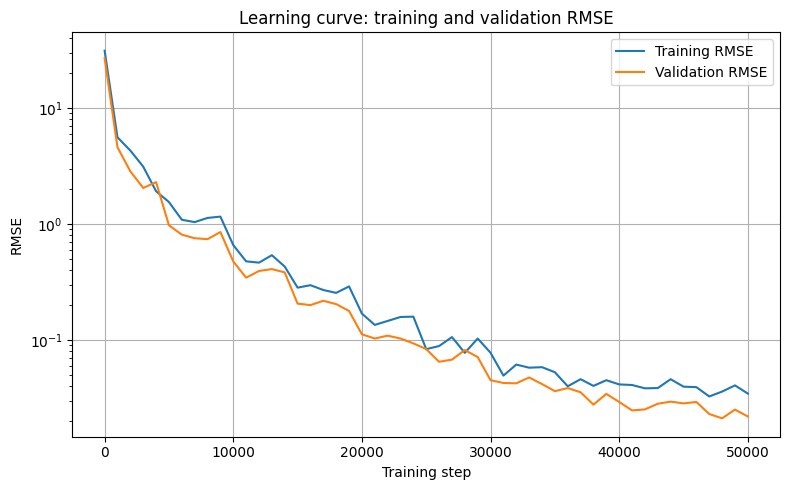

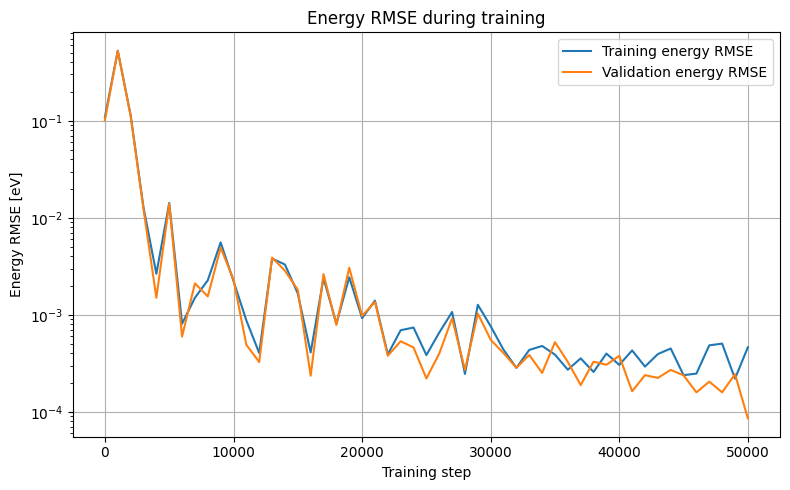

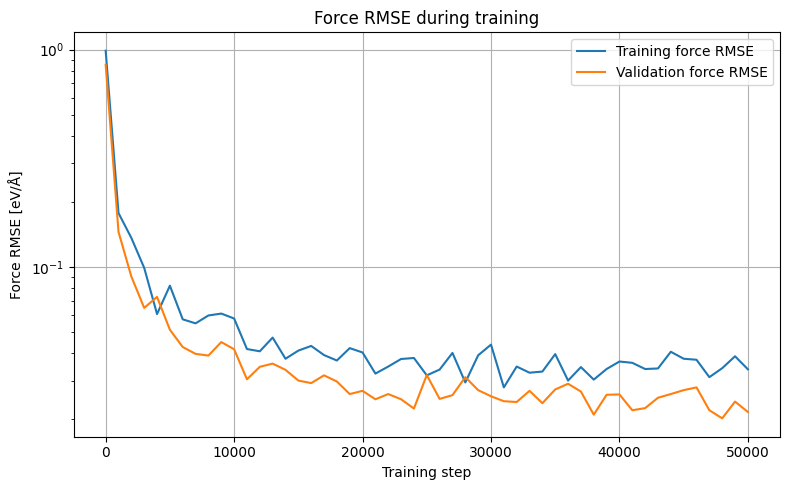

In [ ]:
# 1. Learning Curve
lcurve = pd.read_csv(
    lcurve_path,
    delim_whitespace=True,
    comment="#",
    names=[
        "step",
        "rmse_val",
        "rmse_trn",
        "rmse_e_val",
        "rmse_e_trn",
        "rmse_f_val",
        "rmse_f_trn",
        "lr"
    ]
)

print(lcurve.head())
print(lcurve.tail())

plt.figure(figsize=(8, 5))
plt.plot(lcurve["step"], lcurve["rmse_trn"], label="Training RMSE")
plt.plot(lcurve["step"], lcurve["rmse_val"], label="Validation RMSE")
plt.xlabel("Training step")
plt.ylabel("RMSE")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.title("Learning curve: training and validation RMSE")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "learning_curve_rmse.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(lcurve["step"], lcurve["rmse_e_trn"], label="Training energy RMSE")
plt.plot(lcurve["step"], lcurve["rmse_e_val"], label="Validation energy RMSE")
plt.xlabel("Training step")
plt.ylabel("Energy RMSE [eV]")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.title("Energy RMSE during training")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "learning_curve_energy_rmse.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(lcurve["step"], lcurve["rmse_f_trn"], label="Training force RMSE")
plt.plot(lcurve["step"], lcurve["rmse_f_val"], label="Validation force RMSE")
plt.xlabel("Training step")
plt.ylabel("Force RMSE [eV/Å]")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.title("Force RMSE during training")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "learning_curve_force_rmse.png", dpi=300)
plt.show()


In [ ]:
# 2. AIMD energy data

# train = 500 K
energy_500 = np.load(energy_train_path).flatten()

# validation + test = 298 K
energy_validation = np.load(energy_validation_path).flatten()
energy_test = np.load(energy_test_path).flatten()
energy_298 = np.concatenate([energy_validation, energy_test])

frames_298 = np.arange(len(energy_298))
frames_500 = np.arange(len(energy_500))

plt.figure(figsize=(8, 5))
plt.plot(frames_298, energy_298, label="FAD 298 K")
plt.plot(frames_500, energy_500, label="FAD 500 K")
plt.xlabel("Frame")
plt.ylabel("Energy [eV]")
plt.grid(True)
plt.legend()
plt.title("AIMD potential energy")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "aimd_energy.png", dpi=300)
plt.show()

# Relative energy, easier to compare
energy_298_rel = energy_298 - energy_298.min()
energy_500_rel = energy_500 - energy_500.min()

plt.figure(figsize=(8, 5))
plt.plot(frames_298, energy_298_rel, label="FAD 298 K")
plt.plot(frames_500, energy_500_rel, label="FAD 500 K")
plt.xlabel("Frame")
plt.ylabel("Relative energy [eV]")
plt.grid(True)
plt.legend()
plt.title("Relative AIMD potential energy")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "aimd_relative_energy.png", dpi=300)
plt.show()

In [ ]:
# 3. Energy histograms

plt.figure(figsize=(8, 5))
plt.hist(energy_298, bins=40, alpha=0.6, label="FAD 298 K")
plt.hist(energy_500, bins=40, alpha=0.6, label="FAD 500 K")
plt.xlabel("Energy [eV]")
plt.ylabel("Number of frames")
plt.grid(True)
plt.legend()
plt.title("Energy distribution in AIMD datasets")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "energy_histogram.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(energy_298_rel, bins=40, alpha=0.6, label="FAD 298 K")
plt.hist(energy_500_rel, bins=40, alpha=0.6, label="FAD 500 K")
plt.xlabel("Relative energy [eV]")
plt.ylabel("Number of frames")
plt.grid(True)
plt.legend()
plt.title("Relative energy distribution in AIMD datasets")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "relative_energy_histogram.png", dpi=300)
plt.show()

In [ ]:
# 4. dp test error metrics

# Values from your latest dp test on the test set
error_metrics = {
    "Energy MAE [eV]": 1.972925e-03,
    "Energy RMSE [eV]": 2.492732e-03,
    "Force MAE [eV/Å]": 1.909769e-02,
    "Force RMSE [eV/Å]": 2.477943e-02
}

plt.figure(figsize=(8, 5))
plt.bar(error_metrics.keys(), error_metrics.values())
plt.ylabel("Error value")
plt.yscale("log")
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y")
plt.title("Model prediction errors from dp test")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "dp_test_error_metrics.png", dpi=300)
plt.show()

In [ ]:
# Bond length analysis
bond_csv = LAMMPS_DIR / "mlp_bond_distances.csv"
bond_plot = PLOTS_DIR / "mlp_bond_length_histogram.png"

if not dump_path.exists():
    raise FileNotFoundError(f"Cannot find dump file: {dump_path}")

# Read LAMMPS dump frames

def read_lammps_dump(dump_path):
    timesteps = []
    frames = []

    with open(dump_path, "r") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        if lines[i].startswith("ITEM: TIMESTEP"):
            step = int(lines[i + 1].strip())

            if not lines[i + 2].startswith("ITEM: NUMBER OF ATOMS"):
                raise ValueError("Unexpected dump format: missing NUMBER OF ATOMS")

            natoms = int(lines[i + 3].strip())

            # Find ATOMS header
            atom_header_idx = None
            for j in range(i + 4, len(lines)):
                if lines[j].startswith("ITEM: ATOMS"):
                    atom_header_idx = j
                    break

            if atom_header_idx is None:
                raise ValueError("Could not find ITEM: ATOMS section")

            columns = lines[atom_header_idx].split()[2:]
            atom_lines = lines[atom_header_idx + 1 : atom_header_idx + 1 + natoms]

            frame = pd.DataFrame(
                [line.split() for line in atom_lines],
                columns=columns
            )

            for col in frame.columns:
                frame[col] = pd.to_numeric(frame[col])

            # Keep atoms sorted by id
            frame = frame.sort_values("id").reset_index(drop=True)

            timesteps.append(step)
            frames.append(frame)

            i = atom_header_idx + 1 + natoms
        else:
            i += 1

    return timesteps, frames


timesteps, frames = read_lammps_dump(dump_path)

print("Number of frames read:", len(frames))
print("First timestep:", timesteps[0])
print("Last timestep:", timesteps[-1])
print("Columns:", frames[0].columns.tolist())

# LAMMPS atom types must match type_map.raw:
# 1 = H, 2 = C, 3 = O

type_map = {
    1: "H",
    2: "C",
    3: "O"
}

def distance(a, b):
    return np.linalg.norm(a - b)

# Distance criteria for typical bonds in formic acid
# Keys are sorted alphabetically to avoid C-H / H-C problems
bond_rules = {
    ("C", "H"): (0.8, 1.3),
    ("C", "O"): (1.0, 1.6),
    ("H", "O"): (0.7, 1.2)
}

bond_labels = {
    ("C", "H"): "C-H",
    ("C", "O"): "C-O",
    ("H", "O"): "O-H"
}

bond_records = []

for step, frame in zip(timesteps, frames):
    coords = frame[["x", "y", "z"]].values
    types = frame["type"].astype(int).values
    ids = frame["id"].astype(int).values

    for i in range(len(frame)):
        for j in range(i + 1, len(frame)):
            elem_i = type_map[types[i]]
            elem_j = type_map[types[j]]

            pair = tuple(sorted([elem_i, elem_j]))
            d = distance(coords[i], coords[j])

            if pair in bond_rules:
                d_min, d_max = bond_rules[pair]

                if d_min <= d <= d_max:
                    bond_records.append({
                        "Step": step,
                        "Atom_i": ids[i],
                        "Atom_j": ids[j],
                        "Element_i": elem_i,
                        "Element_j": elem_j,
                        "Bond_type": bond_labels[pair],
                        "Distance_A": d
                    })

bond_df = pd.DataFrame(bond_records)

print("Detected bond distances:")
display(bond_df.head())

print("Number of detected distances:", len(bond_df))

if len(bond_df) == 0:
    raise ValueError("No bond distances were detected. Check atom types or distance cutoffs.")

bond_df.to_csv(bond_csv, index=False)

print("Saved bond distances to:")
print(bond_csv)

# Plot histogram


plt.figure(figsize=(8, 5))

for bond_type in sorted(bond_df["Bond_type"].unique()):
    subset = bond_df[bond_df["Bond_type"] == bond_type]
    plt.hist(
        subset["Distance_A"],
        bins=30,
        alpha=0.5,
        label=bond_type
    )

plt.xlabel("Bond distance [Å]")
plt.ylabel("Count")
plt.title("Distribution of selected bond lengths in MLP trajectory")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(bond_plot, dpi=300)
plt.show()

print("Saved plot to:")
print(bond_plot)

In [ ]:
# Potential energy histogram

plt.figure(figsize=(8, 5))
plt.hist(log_df["PotEng"], bins=30)
plt.xlabel("Potential energy [eV]")
plt.ylabel("Count")
plt.title("Distribution of potential energy in MLP trajectory")
plt.grid(True)
plt.tight_layout()

energy_hist_path = PLOTS_DIR / "mlp_potential_energy_histogram.png"
plt.savefig(energy_hist_path, dpi=300)
plt.show()

print("Saved:")
print(energy_hist_path)


# Potential energy vs MD step

plt.figure(figsize=(8, 5))
plt.plot(log_df["Step"], log_df["PotEng"])
plt.xlabel("MD step")
plt.ylabel("Potential energy [eV]")
plt.title("LAMMPS MLP potential energy during simulation")
plt.grid(True)
plt.tight_layout()

energy_step_path = PLOTS_DIR / "mlp_potential_energy_vs_step.png"
plt.savefig(energy_step_path, dpi=300)
plt.show()

print("Saved:")
print(energy_step_path)

# Temperature vs MD step

plt.figure(figsize=(8, 5))
plt.plot(log_df["Step"], log_df["Temp"])
plt.xlabel("MD step")
plt.ylabel("Temperature [K]")
plt.title("Temperature during LAMMPS MLP simulation")
plt.grid(True)
plt.tight_layout()

temperature_path = PLOTS_DIR / "mlp_temperature_vs_step.png"
plt.savefig(temperature_path, dpi=300)
plt.show()

print("Saved:")
print(temperature_path)

In [ ]:
# Summary

print("Saved plots to:")
print(PLOTS_DIR)

print("\nGenerated files:")
for file in sorted(PLOTS_DIR.iterdir()):
    if file.suffix == ".png":
        print(file.name)